In [1]:
%load_ext autoreload
%autoreload 2
%cd /home/xux/Desktop/AlphaVariant/Benchmark

/home/xux/Desktop/AlphaVariant/Benchmark


# Ranking panel — average method rank across datasets

Two side-by-side lollipop panels (four-site GB1/PhoQ/TrpB; multi-site AAV/CreiLOV/PAB1).
Each method's mean rank across the group's datasets is shown as:
- **gray dots** — rank in one individual dataset (darkened for print)
- **open circles** — mean rank across datasets  
- **filled vermilion circle** — AlphaVariant mean rank

Rank 1 (best) is on the **left**; a ← better directional arrow marks the axis.

Ranks are computed live from the same median CSVs used by the performance figures.

Outputs (PNG + PDF + SVG) are written to `figures/`.

In [ ]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

sys.path.insert(0, '.')
from utils.plot_style_utils import VERMILION, apply_nature_rcparams, save_figure

FIGURES_DIR = 'figures'

# Palette
ALPHA_RED    = VERMILION
DOT_GRAY     = '#8A8A8A'
DOT_GRAY_EDGE = '#5F5F5F'
LINE_GRAY    = '#D4D4D4'
GRID_GRAY    = '#E6E6E6'
TEXT_GRAY    = '#444444'

apply_nature_rcparams({
    'font.size': 7.5,   # uniform base size for this panel-style figure
})

DISPLAY_NAMES = {'FLEXS': 'AdaLead'}

# Canonical 10-method order (best → worst by 4-site mean rank; ties fall back to this order)
METHOD_ORDER = [
    'Random', 'GreedyWalk', 'ftMLDE', 'ALDE', 'CLADE',
    'EVOLVEpro', 'MULTIevolve', 'AiCE', 'AdaLead', 'AlphaVariant',
]

print('Setup complete.')

## Group configuration

Edit the dataset lists here to add or remove datasets.
TEV (4-site) and GFP (multi-site) are intentionally excluded.

In [3]:
MAIN_METHODS_4SITE = {
    'Random', 'GreedyWalk', 'ALDE', 'FLEXS', 'AiCE',
    'ftMLDE', 'CLADE', 'AlphaVariant', 'MULTIevolve', 'EVOLVEpro',
}
MAIN_METHODS_MULTISITE = {
    'Random', 'GreedyWalk', 'ALDE', 'CLADE', 'ftMLDE',
    'AdaLead', 'MULTIevolve', 'EVOLVEpro', 'AiCE', 'AlphaVariant',
}

GROUPS = {
    'Four-site': {
        'csv': os.path.join(FIGURES_DIR, 'alphavariant_comparison_median_iqr.csv'),
        'allow': MAIN_METHODS_4SITE,
        'dataset_labels': {
            '4site_GB1': 'GB1',
            '4site_PhoQ': 'PhoQ',
            '4site_TRPB': 'TrpB',
        },
    },
    'Multi-site': {
        'csv': os.path.join(FIGURES_DIR, 'ms_oracles', 'multisite_oracle_median_iqr.csv'),
        'allow': MAIN_METHODS_MULTISITE,
        'dataset_labels': {
            'ms_AAV': 'AAV',
            'ms_CreiLOV': 'CreiLOV',
            'ms_PAB1': 'PAB1',
        },
    },
}

print('Group configs loaded.')

Group configs loaded.


## Build rank tables

In [4]:
def build_rank_table(group_cfg, metric_col):
    """Rank methods within each dataset; return method × dataset table + Mean rank."""
    df = pd.read_csv(group_cfg['csv'])
    df = df[df['method'].isin(group_cfg['allow'])].copy()
    df['method'] = df['method'].replace(DISPLAY_NAMES)

    datasets = list(group_cfg['dataset_labels'].keys())
    df = df[df['dataset'].isin(datasets)]

    df['rank'] = df.groupby('dataset')[metric_col].rank(ascending=False, method='average')

    table = df.pivot(index='method', columns='dataset', values='rank')
    table = table.reindex(METHOD_ORDER).dropna(how='all')
    table = table[[d for d in datasets if d in table.columns]]
    table['Mean rank'] = table.mean(axis=1, skipna=True)
    table = table.sort_values('Mean rank', ascending=True, na_position='last')
    return table


# Choose metric: 'max_fitness_median' or 'top128_median'
METRIC_COL   = 'max_fitness_median'
METRIC_LABEL = 'max fitness'

tables = {}
for group, cfg in GROUPS.items():
    tables[group] = build_rank_table(cfg, METRIC_COL)
    print(f'{group}:')
    print(tables[group][['Mean rank']].to_string())
    print()

Four-site:
dataset       Mean rank
method                 
ALDE           2.333333
MULTIevolve    2.333333
ftMLDE         3.166667
AlphaVariant   3.166667
AdaLead        4.666667
CLADE          5.500000
GreedyWalk     6.833333
AiCE           8.333333
EVOLVEpro      8.666667
Random        10.000000

Multi-site:
dataset       Mean rank
method                 
AlphaVariant   1.000000
AdaLead        3.000000
ftMLDE         3.333333
GreedyWalk     4.000000
AiCE           5.333333
MULTIevolve    5.666667
CLADE          6.333333
EVOLVEpro      7.666667
ALDE           8.666667
Random        10.000000



## Draw ranking panel

In [ ]:
def _draw_group(ax, table, title, n_methods):
    methods = table.index.tolist()[::-1]  # best mean rank at the top
    tp = table.loc[methods]
    dataset_cols = [c for c in tp.columns if c != 'Mean rank']
    y = np.arange(len(tp))
    mean_rank = tp['Mean rank'].to_numpy(float)

    worst = n_methods
    ax.hlines(y, worst, mean_rank, color=LINE_GRAY, lw=1.05, zorder=1)

    offsets = np.linspace(-0.20, 0.20, len(dataset_cols))
    for di, ds in enumerate(dataset_cols):
        vals = tp[ds].to_numpy(float)
        mask = ~np.isnan(vals)
        ax.scatter(vals[mask], y[mask] + offsets[di], s=14,
                   facecolor=DOT_GRAY, edgecolor=DOT_GRAY_EDGE,
                   linewidth=0.25, alpha=0.85, zorder=2)

    is_alpha = np.array([m == 'AlphaVariant' for m in tp.index])
    ax.scatter(mean_rank[~is_alpha], y[~is_alpha], s=46, facecolor='white',
               edgecolor='#202020', linewidth=1.05, zorder=4)
    ax.scatter(mean_rank[is_alpha], y[is_alpha], s=58, facecolor=ALPHA_RED,
               edgecolor='white', linewidth=0.75, zorder=5)

    ax.set_title(title, loc='left', fontsize=9.2, weight='bold', pad=8)
    ax.set_yticks(y)
    ax.set_yticklabels(tp.index, fontsize=7.1)
    for lab in ax.get_yticklabels():
        if lab.get_text() == 'AlphaVariant':
            lab.set_color(ALPHA_RED)
            lab.set_fontweight('bold')

    ax.set_xlim(0.55, worst + 0.4)   # Rank 1 (best) on the left
    ticks = sorted({1, 2, 4, 6, 8, worst})
    ax.set_xticks([t for t in ticks if t <= worst])
    ax.set_xlabel('Mean rank (1 = best)', fontsize=7.2, labelpad=14)
    ax.grid(axis='x', color=GRID_GRAY, lw=0.6)
    ax.set_axisbelow(True)
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.spines['bottom'].set_linewidth(0.65)
    ax.tick_params(axis='y', length=0, pad=3)
    ax.tick_params(axis='x', labelsize=7.0, length=3.0, pad=2)

    ax.annotate('better', xy=(0.0, -0.155), xytext=(0.30, -0.155),
                xycoords='axes fraction', textcoords='axes fraction',
                fontsize=6.6, color=TEXT_GRAY, va='center', ha='left',
                arrowprops=dict(arrowstyle='->', color=TEXT_GRAY, lw=0.8))


def draw_ranking_panel(tables, metric_label, outdir, prefix,
                       n_seeds=30, save=True):
    fig = plt.figure(figsize=(5.6, 3.55), dpi=120)
    gs = fig.add_gridspec(1, 2, left=0.135, right=0.985,
                          bottom=0.30, top=0.80, wspace=0.55)
    for gi, (group, table) in enumerate(tables.items()):
        ax = fig.add_subplot(gs[0, gi])
        _draw_group(ax, table, f'{group} rankings', len(table))

    fig.text(0.045, 0.945, 'Average method ranking across datasets',
             fontsize=10.6, fontweight='bold')
    fig.text(0.045, 0.875,
             f'Ranked by {metric_label} (median across {n_seeds} independent seeds per method per dataset)',
             fontsize=7.0, color=TEXT_GRAY)

    legend_handles = [
        mlines.Line2D([0], [0], marker='o', color='none', markersize=5.5,
                      markerfacecolor=DOT_GRAY, markeredgecolor=DOT_GRAY_EDGE,
                      markeredgewidth=0.4, label='Rank in one dataset'),
        mlines.Line2D([0], [0], marker='o', color='none', markersize=7,
                      markerfacecolor='white', markeredgecolor='#202020',
                      markeredgewidth=1.1, label='Mean rank across datasets'),
        mlines.Line2D([0], [0], marker='o', color='none', markersize=7.5,
                      markerfacecolor=ALPHA_RED, markeredgecolor='white',
                      markeredgewidth=0.75, label='AlphaVariant mean rank'),
    ]
    fig.legend(handles=legend_handles, loc='lower center',
               bbox_to_anchor=(0.56, 0.00), ncol=3, frameon=False,
               fontsize=6.0, handletextpad=0.4, columnspacing=1.0)

    if save:
        save_figure(fig, outdir, prefix)

    plt.show()
    return fig


print('Helpers defined.')

## Ranking panel — max fitness

  Saved: figures/ranking_panel_max_fitness.pdf
  Saved: figures/ranking_panel_max_fitness.png
  Saved: figures/ranking_panel_max_fitness.svg


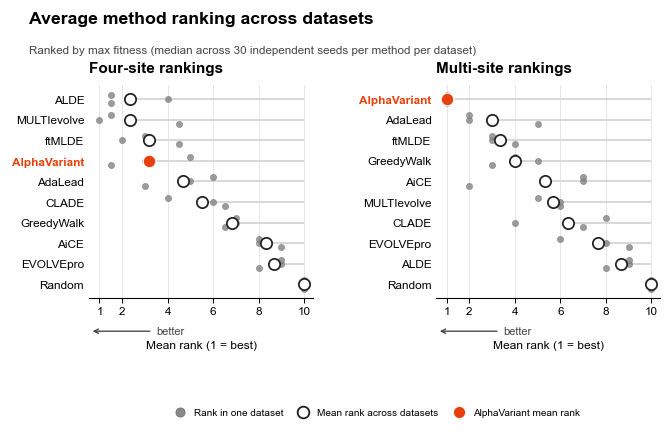

In [6]:
METRIC_COL   = 'max_fitness_median'
METRIC_LABEL = 'max fitness'
PREFIX       = 'ranking_panel_max_fitness'

tables = {group: build_rank_table(cfg, METRIC_COL) for group, cfg in GROUPS.items()}

fig = draw_ranking_panel(tables, METRIC_LABEL, FIGURES_DIR, PREFIX)

## Ranking panel — top-128 mean fitness (supplementary)

  Saved: figures/ranking_panel_top128.pdf
  Saved: figures/ranking_panel_top128.png
  Saved: figures/ranking_panel_top128.svg


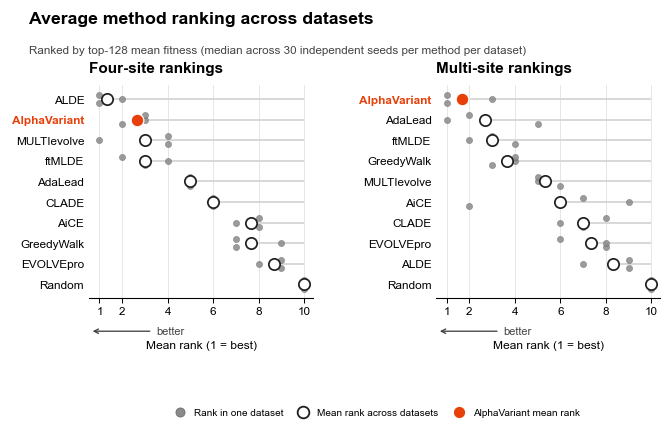

In [7]:
METRIC_COL   = 'top128_median'
METRIC_LABEL = 'top-128 mean fitness'
PREFIX       = 'ranking_panel_top128'

tables = {group: build_rank_table(cfg, METRIC_COL) for group, cfg in GROUPS.items()}

fig = draw_ranking_panel(tables, METRIC_LABEL, FIGURES_DIR, PREFIX)

## Export rank values to CSV

In [8]:
# Recompute tables for the chosen metric and export
METRIC_COL   = 'max_fitness_median'
PREFIX       = 'ranking_panel_max_fitness'

tables = {group: build_rank_table(cfg, METRIC_COL) for group, cfg in GROUPS.items()}
csv_path = os.path.join(FIGURES_DIR, f'{PREFIX}_values.csv')
pd.concat({g: t for g, t in tables.items()}, names=['group']).to_csv(csv_path)
print(f'Rank values saved to: {csv_path}')

Rank values saved to: figures/ranking_panel_max_fitness_values.csv
